# Comparação entre dados reais e dados simulados

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

## Exibindo o mapa de latitude e longitude

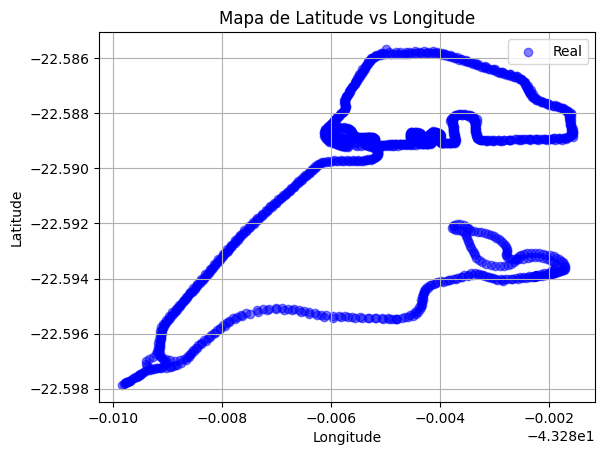

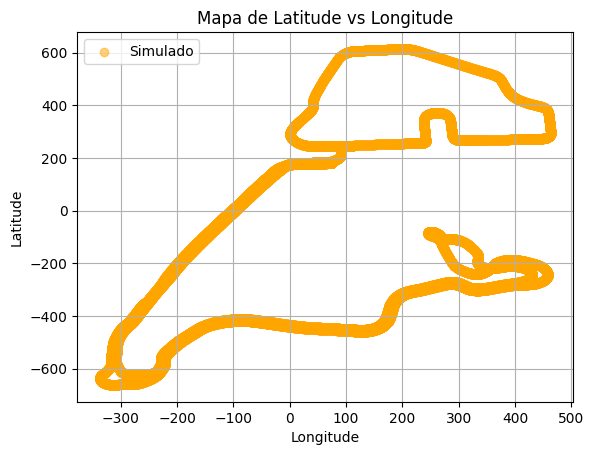

In [70]:
real = pd.read_csv('CSVLog_20260121_150221.csv')

# Recortando a entrada ao campus no mapa real
real = real[real[' Latitude (deg)'] > -22.5979]

s_circuito1 = pd.read_csv('../data/Circuito 1/s_20260313_2220/readable.csv', sep=';')
s_circuito2 = pd.read_csv('../data/Circuito 2/s_20260313_2254/readable.csv', sep=';')

circuitos_concatenados = pd.concat([s_circuito1, s_circuito2], ignore_index=True)

# Plotando mapa Lat Long para dados reais
plt.scatter(real[' Longitude (deg)'], real[' Latitude (deg)'], label='Real', alpha=0.5
            , color='blue')
plt.title('Mapa de Latitude vs Longitude')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.grid()
plt.show()

# Plotando mapa Lat Long para dados simulados
plt.scatter(circuitos_concatenados['posX'], circuitos_concatenados['posY'], label='Simulado', alpha=
            0.5, color='orange')
plt.title('Mapa de Latitude vs Longitude')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.grid()
plt.show()

## Verificar comportamento das medidas entre simulado e real

### 1º: Velocidade do veículo

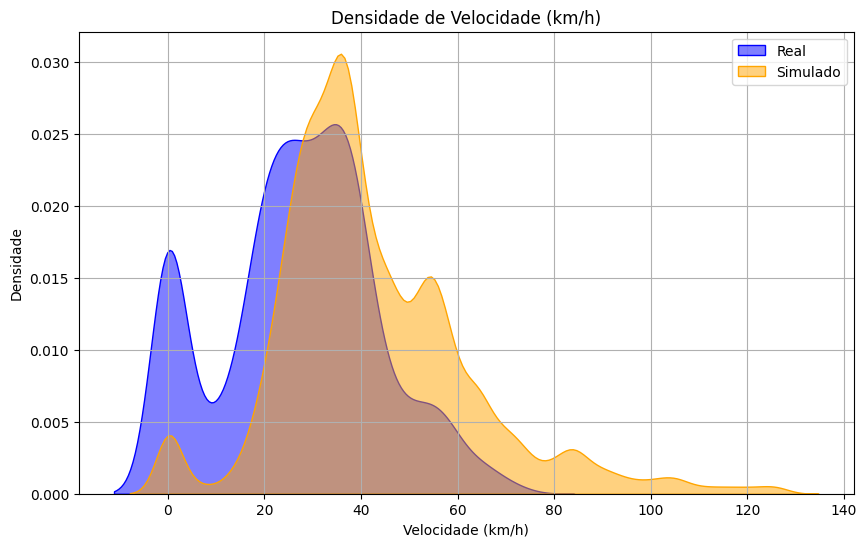

In [71]:
import ast

circuitos_concatenados['vel'] = circuitos_concatenados['vel'].apply(ast.literal_eval)

# Convertendo a velocidade vetorial da simulação para km/h, (cada entrada da coluna vel é uma tripla de velocidade em x, y e z)
circuitos_concatenados['Velocidade_kmh'] = circuitos_concatenados['vel'].apply(
    lambda v: np.sqrt(v[0]**2 + v[1]**2 + v[2]**2) * 3.6
)

# Plotando gráfico de densidade para velocidade real vs simulada
plt.figure(figsize=(10, 6))
sns.kdeplot(real[' Velocidade do veículo (km/h)'], label='Real', fill=True, alpha=0.5, color='blue')
sns.kdeplot(circuitos_concatenados['Velocidade_kmh'], label='Simulado', fill=True, alpha=0.5, color='orange')
plt.title('Densidade de Velocidade (km/h)')
plt.xlabel('Velocidade (km/h)')
plt.ylabel('Densidade')
plt.legend()
plt.grid()
plt.show()

In [73]:
# Executando o teste de smirnov para comparar as distribuições de velocidade real e simulada
from scipy.stats import ks_2samp

statistic, p_value = ks_2samp(real[' Velocidade do veículo (km/h)'], circuitos_concatenados['Velocidade_kmh'])
print(f'Estatística KS: {statistic:.4f}')
print(f'Valor-p: {p_value:.4f}')

if p_value < 0.05:
    print('As distribuições de velocidade real e simulada são significativamente diferentes.')
else:
    print('Não há evidências suficientes para afirmar que as distribuições de velocidade real e simulada são diferentes.')

Estatística KS: 0.3249
Valor-p: 0.0000
As distribuições de velocidade real e simulada são significativamente diferentes.


### 2º: Posições de pedal

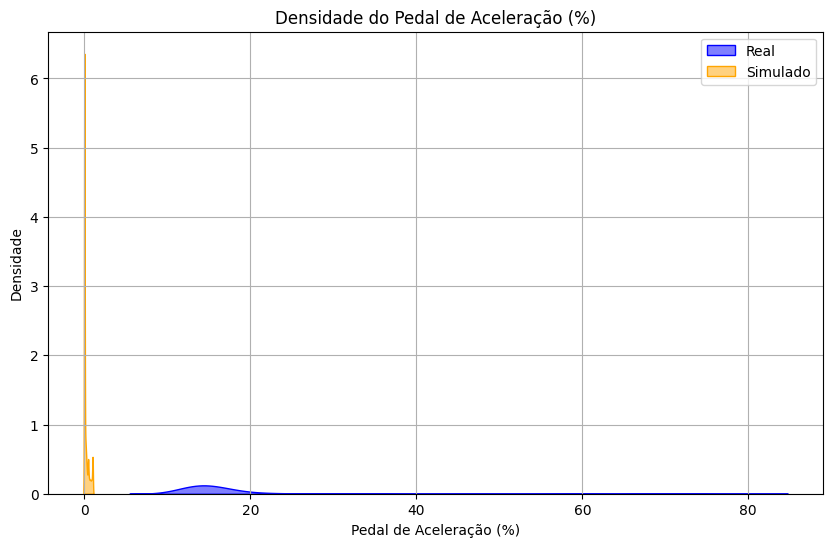

In [80]:
# Plotando densidade para posicação do pedal de aceleração
plt.figure(figsize=(10, 6))
sns.kdeplot(real[' Posição absoluta do acelerador (%)'], label='Real', fill=True, alpha=0.5, color='blue')
sns.kdeplot(circuitos_concatenados['throttle'], label='Simulado', fill=True, alpha=0.5, color='orange')
plt.title('Densidade do Pedal de Aceleração (%)')
plt.xlabel('Pedal de Aceleração (%)')
plt.ylabel('Densidade')
plt.legend()
plt.grid()
plt.show()